# 1. Signal Validation & IC Analysis

This notebook demonstrates the standalone evaluation of the Physical Activity Index (PAI) and the Analyst Momentum Index (AMI), as well as the predictive power of their Divergence Signal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Ensure the project root is in the path so we can import local modules
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from signals.pai_constructor import PAIConstructor
from signals.ami_constructor import AMIConstructor
from signals.divergence_signal import DivergenceSignal
from backtest.ic_analysis import ICAnalyzer

sns.set_theme(style="darkgrid")

## Generate Mock Signals
In a real environment, this data would be pulled from the database containing historic pipeline runs.

In [2]:
# Setup mock data
dates = pd.date_range(start="2020-01-01", end="2022-12-31", freq="B")
tickers = [f"TICK_{i}" for i in range(1, 101)]

# Create randomized signal datasets
np.random.seed(42)
records = []
for d in dates:
    for t in tickers:
        records.append({
            "date": d,
            "ticker": t,
            "pai_zscore": np.random.normal(0, 1),
            "ami_zscore": np.random.normal(0, 1),
            "industry": f"IND_{np.random.randint(1, 10)}"
        })
        
mock_signals = pd.DataFrame(records)

## Build the Divergence Signal

In [3]:
diverger = DivergenceSignal(use_smoothing=True)

# Merge (pai and ami are mocked as already existing in mock_signals)
final_signals = diverger.generate_signal(
    mock_signals[['ticker', 'date', 'pai_zscore']], 
    mock_signals[['ticker', 'date', 'ami_zscore']],
    industry_map=mock_signals[['ticker', 'industry']].drop_duplicates()
)

final_signals.head()

,ticker,date,pai_zscore,ami_zscore,delta_signal_raw,industry,industry_rank,delta_signal_smooth
0,TICK_1,2020-01-01,0.496714,-0.138264,0.634978,IND_8,0.69,0.634978
1,TICK_1,2020-01-01,0.496714,-0.138264,0.634978,IND_7,0.69,0.634978
2,TICK_1,2020-01-01,0.496714,-0.138264,0.634978,IND_4,0.69,0.634978
3,TICK_1,2020-01-01,0.496714,-0.138264,0.634978,IND_3,0.69,0.634978
4,TICK_1,2020-01-01,0.496714,-0.138264,0.634978,IND_2,0.69,0.634978


## Run Information Coefficient (IC) Analysis
We test how well our `delta_signal_smooth` predicts analyst estimate revisions 1-30 days out.

In [4]:
analyzer = ICAnalyzer(forward_windows=[1, 3, 5, 10, 15, 20, 30])

# Calculate matching mock forward targets
forward_targets = analyzer.calculate_forward_revisions(None, dates, tickers)

# Run the analysis
ic_results = analyzer.run_ic_analysis(final_signals, forward_targets)
ic_results

,Forward_Window,IC_Mean,IC_Std,ICIR,t_stat,Observations
0,1 Days,-0.002126,0.094257,-0.022559,-0.631252,783
1,3 Days,-0.000282,0.096736,-0.002915,-0.081581,783
2,5 Days,-0.003112,0.085959,-0.036207,-1.013143,783
3,10 Days,-0.004806,0.090561,-0.053064,-1.484852,783
4,15 Days,-0.001355,0.089896,-0.015070,-0.421682,783
5,20 Days,0.000443,0.093924,0.004716,0.131964,783
6,30 Days,-0.001545,0.094287,-0.016385,-0.458496,783


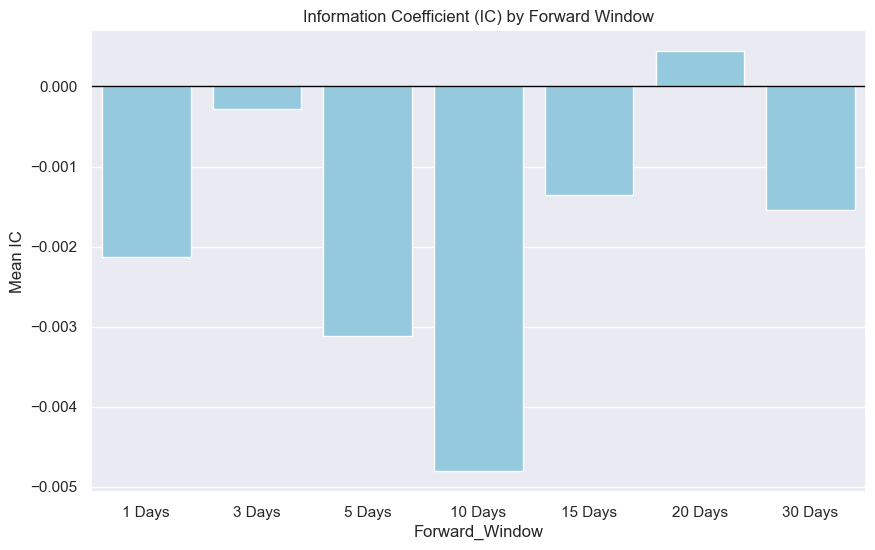

In [5]:
# Plot the IC decay
plt.figure(figsize=(10, 6))
sns.barplot(data=ic_results, x="Forward_Window", y="IC_Mean", color="skyblue")
plt.title("Information Coefficient (IC) by Forward Window")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Mean IC")
plt.show()